In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import string
import pickle
import spacy
import os

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from gensim.models import Word2Vec


In [2]:
def get_tag(tag):
    tag = tag.lower()
    if tag.startswith('j'): return 'a'
    if tag.startswith('v'): return 'v'
    if tag.startswith('n'): return 'n'
    if tag.startswith('r'): return 'r'
    return 'n'

def lemma(removed_stop):
    lemmatizer = WordNetLemmatizer()
    lemmatize = []
    tagged = pos_tag(removed_stop)

    for word, tag in tagged:
        label = get_tag(tag.lower())
        if label:
            result = lemmatizer.lemmatize(word, label)
            lemmatize.append(result)

    return lemmatize

def preprocessing(sentence):
    sentence = sentence.lower()
    punct = string.punctuation
    stop = stopwords.words('english')

    word_list = word_tokenize(sentence)
    word_list = [word for word in word_list if word.isalpha()]

    removed_punct = [token for token in word_list if token not in punct]
    removed_stop = [token for token in removed_punct if token not in stop]
    lemmatized = lemma(removed_stop)

    return lemmatized

nlp = spacy.load("en_core_web_sm")
NER_TYPES = ['ORG', 'PERSON', 'GPE', 'NORP']

def perform_ner(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

def get_entity_dictionary(text):
    doc = nlp(text)
    ent_dict = {t: [] for t in NER_TYPES}
    for ent in doc.ents:
        if ent.label_ in NER_TYPES:
            token = ent.text.strip().lower().replace(" ", "_")
            ent_dict[ent.label_].append(token)
    return {k: " ".join(v) for k, v in ent_dict.items()}


In [3]:
data = pd.read_csv("Political_Bias_Cleaned_Balanced.csv")
data['Title'] = [title + " " + source for (title, source) in zip(data['Title'], data['Source'])]

dropped = ['id', 'Text', 'Link', 'Source']
data = data.drop(dropped, axis=1)

data["cleaned_tokens"] = data["Title"].apply(preprocessing)
data['entity_dict'] = data['Title'].apply(get_entity_dictionary)


In [4]:
print(data['entity_dict'])

0       {'ORG': 'the_'continuing_turmoil'', 'PERSON': ...
1       {'ORG': 'wildfires_inevitable_thedispatch', 'P...
2       {'ORG': '', 'PERSON': '', 'GPE': 'los_angeles'...
3       {'ORG': 'thedispatch', 'PERSON': '', 'GPE': 'g...
4        {'ORG': '', 'PERSON': '', 'GPE': '', 'NORP': ''}
                              ...                        
1900    {'ORG': '', 'PERSON': 'trumps ¦', 'GPE': 'colo...
1901    {'ORG': '', 'PERSON': '', 'GPE': 'california',...
1902    {'ORG': '', 'PERSON': '', 'GPE': 'u.s.', 'NORP...
1903    {'ORG': 'trump air_force', 'PERSON': '', 'GPE'...
1904    {'ORG': '', 'PERSON': 'trump', 'GPE': 'florida...
Name: entity_dict, Length: 1905, dtype: object


In [5]:
NER_FEATURE_BUDGET = {
    'ORG':    300,
    'PERSON': 200,
    'GPE':    150,
    'NORP':   200,
}

ner_vectorizers = {}

def get_entity_features():
    from sklearn.feature_extraction.text import TfidfVectorizer

    entity_vectorizer = TfidfVectorizer(min_df=2, max_features=1000)

    entity_features = entity_vectorizer.fit_transform(data['entity_strings'])

    return entity_features

def ner_features(fit=True):
    parts = []
    for ner_type, max_feat in NER_FEATURE_BUDGET.items():
        strings = data['entity_dict'].apply(lambda d: d[ner_type])
        if fit:
            vec = TfidfVectorizer(min_df=2, max_features=max_feat)
            mat = vec.fit_transform(strings).toarray()
            ner_vectorizers[ner_type] = vec
        else:
            vec = ner_vectorizers[ner_type]
            mat = vec.transform(strings).toarray()
        parts.append(mat)
        print(f"  {ner_type}: {mat.shape[1]} features")
    return np.hstack(parts)

In [6]:
w2v_model = Word2Vec(sentences=data['cleaned_tokens'], vector_size=100, window=5, min_count=1, workers=4)

def get_mean_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if not vectors:
        return np.zeros(100)
    return np.mean(vectors, axis=0)


In [7]:
class NGramLanguageModel:
    def __init__(self, n1, n2):
        self.n1 = n1
        self.n2 = n2
        self.vectorizer = TfidfVectorizer(ngram_range=(n1, n2), max_features=3000)

    def fit_transform(self, corpus):
        return self.vectorizer.fit_transform(corpus)

    def transform(self, corpus):
        return self.vectorizer.transform(corpus)

ngram_model = NGramLanguageModel(n1=1, n2=2)
ngram_features = ngram_model.fit_transform(data['Title'])

In [8]:
le = LabelEncoder()

def train_model():
    w2v_features = np.array(data['cleaned_tokens'].apply(get_mean_vector).tolist())
    tfidf_features = ngram_features.toarray()
    all_ner_feats = ner_features(fit=True)

    # X = np.hstack((w2v_features, tfidf_features, ner_features))
    X = np.hstack((w2v_features, tfidf_features, all_ner_feats))
    y = le.fit_transform(data['Bias'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
    )

    # ComplementNB harus positif
    X_train_pos = X_train - X_train.min(axis=0)
    X_test_pos = X_test - X_train.min(axis=0)

    model = ComplementNB()
    model.fit(X_train_pos, y_train)

    y_pred = model.predict(X_test_pos)

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.2f}")

    with open('model.pkl', 'wb') as f:
        pickle.dump(model, f)

    return model, X_train.min(axis=0), y_test, X_test_pos

model, feat_min, y_test, X_test_pos = train_model()


  ORG: 138 features
  PERSON: 133 features
  GPE: 58 features
  NORP: 20 features
Accuracy: 0.88


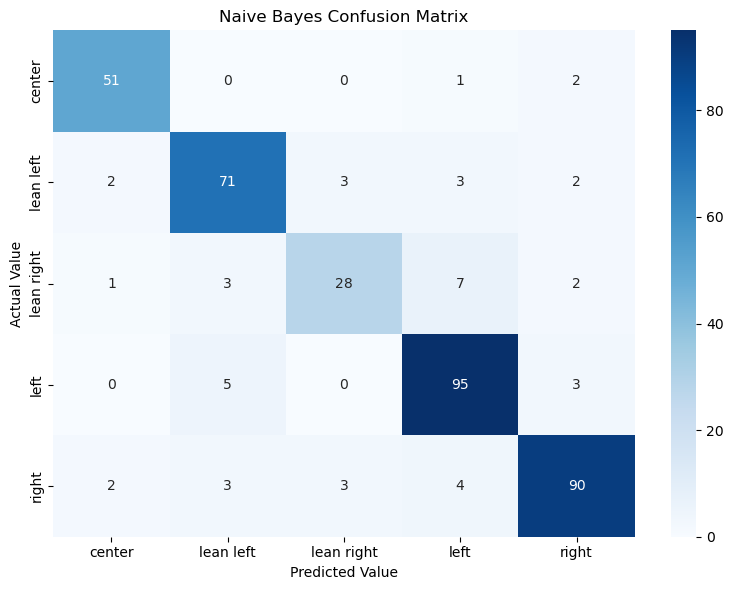

In [9]:
def plot_nb_confusion_matrix():
    if os.path.exists("model.pkl"):
        with open('model.pkl', 'rb') as file:
            loaded_model = pickle.load(file)
            y_pred = loaded_model.predict(X_test_pos)
            cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
            
            plt.title('Naive Bayes Confusion Matrix')
            plt.xlabel('Predicted Value')
            plt.ylabel('Actual Value')
            plt.tight_layout()
            plt.show()
    else:
        print("Naive Bayes model not found. Run train_model() first.")

plot_nb_confusion_matrix()

In [10]:
def get_performance():
    if(os.path.exists("model.pkl")):
        with open('model.pkl', 'rb') as file:
            model = pickle.load(file)
            y_pred = model.predict(X_test_pos)

            labels = le.classes_
            print("Naive Bayes Evaluation")
            print('-'*54)
            print(classification_report(y_pred=y_pred, y_true=y_test, target_names=labels))

            y_prob = model.predict_proba(X_test_pos)
            print(f"Naive Bayes ROC-AUC: {roc_auc_score(y_test, y_prob, multi_class='ovr'):.4f}")

get_performance()

Naive Bayes Evaluation
------------------------------------------------------
              precision    recall  f1-score   support

      center       0.91      0.94      0.93        54
   lean left       0.87      0.88      0.87        81
  lean right       0.82      0.68      0.75        41
        left       0.86      0.92      0.89       103
       right       0.91      0.88      0.90       102

    accuracy                           0.88       381
   macro avg       0.87      0.86      0.87       381
weighted avg       0.88      0.88      0.88       381

Naive Bayes ROC-AUC: 0.9827


In [11]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

def train_svm():
    w2v_features = np.array(data['cleaned_tokens'].apply(get_mean_vector).tolist())
    tfidf_features = ngram_features.toarray()
    all_ner_feats = ner_features(fit=True)

    X = np.hstack((w2v_features, tfidf_features, all_ner_feats))
    y = le.fit_transform(data['Bias'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm_model = SVC(kernel='linear', probability=True, random_state=42)
    svm_model.fit(X_train_scaled, y_train)

    y_pred = svm_model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    print(f"SVM Accuracy: {acc:.2f}")

    with open('svm_model.pkl', 'wb') as f:
        pickle.dump(svm_model, f)
        
    with open('svm_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    return svm_model, scaler, y_test, X_test_scaled

svm_model, svm_scaler, y_test_svm, X_test_svm = train_svm()

  ORG: 138 features
  PERSON: 133 features
  GPE: 58 features
  NORP: 20 features
SVM Accuracy: 0.85


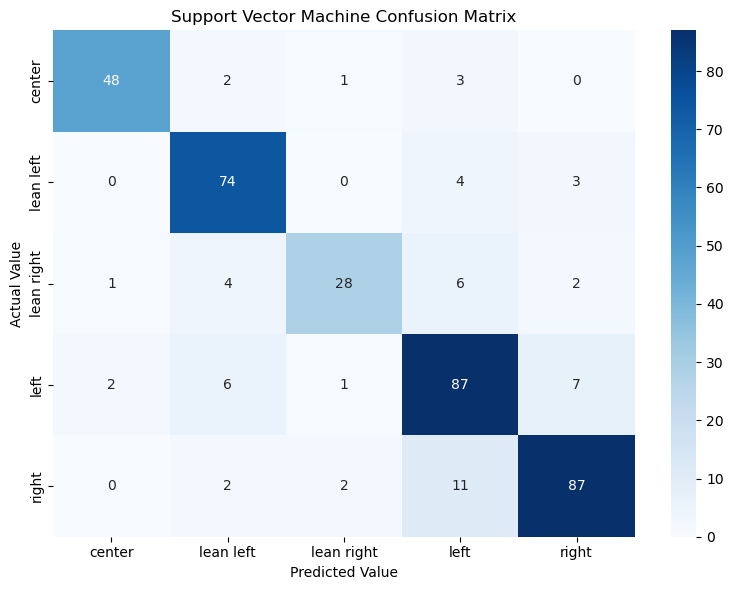

In [12]:
def plot_svm_confusion_matrix():
    if os.path.exists("svm_model.pkl"):
        with open('svm_model.pkl', 'rb') as file:
            loaded_svm = pickle.load(file)
            y_pred = loaded_svm.predict(X_test_svm)
            cm = confusion_matrix(y_true=y_test_svm, y_pred=y_pred)

            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
            
            plt.title('Support Vector Machine Confusion Matrix')
            plt.xlabel('Predicted Value')
            plt.ylabel('Actual Value')
            plt.tight_layout()
            plt.show()
    else:
        print("SVM model not found. Run train_svm() first.")

plot_svm_confusion_matrix()

In [13]:
def get_performance_svm():
    if os.path.exists("svm_model.pkl"):
        with open('svm_model.pkl', 'rb') as file:
            loaded_svm = pickle.load(file)
            y_pred = loaded_svm.predict(X_test_svm)

            labels = le.classes_
            print("SVM Evaluation")
            print('-'*54)
            print(classification_report(y_true=y_test_svm, y_pred=y_pred, target_names=labels))

            y_prob = loaded_svm.predict_proba(X_test_svm)
            print(f"SVM ROC-AUC: {roc_auc_score(y_test_svm, y_prob, multi_class='ovr'):.4f}")
    else:
        print("SVM model not found. Run train_svm() first.")

get_performance_svm()

SVM Evaluation
------------------------------------------------------
              precision    recall  f1-score   support

      center       0.94      0.89      0.91        54
   lean left       0.84      0.91      0.88        81
  lean right       0.88      0.68      0.77        41
        left       0.78      0.84      0.81       103
       right       0.88      0.85      0.87       102

    accuracy                           0.85       381
   macro avg       0.86      0.84      0.85       381
weighted avg       0.85      0.85      0.85       381

SVM ROC-AUC: 0.9800


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def train_logistic_regression():
    w2v_features = np.array(data['cleaned_tokens'].apply(get_mean_vector).tolist())
    tfidf_features = ngram_features.toarray()
    all_ner_feats = ner_features(fit=True)

    X = np.hstack((w2v_features, tfidf_features, all_ner_feats))
    y = le.fit_transform(data['Bias'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_scaled, y_train)

    y_pred = lr_model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    print(f"Logistic Regression Accuracy: {acc:.2f}")

    with open('lr_model.pkl', 'wb') as f:
        pickle.dump(lr_model, f)
        
    with open('lr_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    return lr_model, scaler, y_test, X_test_scaled

lr_model, lr_scaler, y_test_lr, X_test_lr = train_logistic_regression()

  ORG: 138 features
  PERSON: 133 features
  GPE: 58 features
  NORP: 20 features
Logistic Regression Accuracy: 0.87


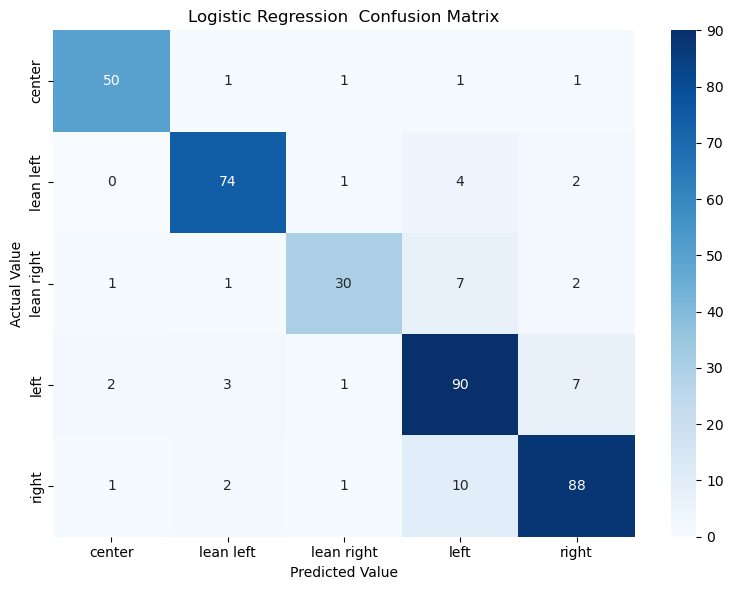

In [15]:
def plot_lr_confusion_matrix():
    if os.path.exists("lr_model.pkl"):
        with open('lr_model.pkl', 'rb') as file:
            loaded_lr = pickle.load(file)
            y_pred = loaded_lr.predict(X_test_lr)
            cm = confusion_matrix(y_true=y_test_lr, y_pred=y_pred)

            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
            
            plt.title('Logistic Regression  Confusion Matrix')
            plt.xlabel('Predicted Value')
            plt.ylabel('Actual Value')
            plt.tight_layout()
            plt.show()
    else:
        print("Logistic Regression model not found. Run train_logistic_regression() first.")

plot_lr_confusion_matrix()

In [16]:
def get_performance_logistic_regression():
    if os.path.exists("lr_model.pkl"):
        with open('lr_model.pkl', 'rb') as file:
            loaded_lr = pickle.load(file)
            y_pred = loaded_lr.predict(X_test_lr)

            labels = le.classes_
            print("Logistic Regression Evaluation")
            print('-'*54)
            print(classification_report(y_true=y_test_lr, y_pred=y_pred, target_names=labels))

            y_prob = loaded_lr.predict_proba(X_test_lr)
            print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test_lr, y_prob, multi_class='ovr'):.4f}")
    else:
        print("Logistic Regression model not found. Run train_logistic_regression() first.")

get_performance_logistic_regression()

Logistic Regression Evaluation
------------------------------------------------------
              precision    recall  f1-score   support

      center       0.93      0.93      0.93        54
   lean left       0.91      0.91      0.91        81
  lean right       0.88      0.73      0.80        41
        left       0.80      0.87      0.84       103
       right       0.88      0.86      0.87       102

    accuracy                           0.87       381
   macro avg       0.88      0.86      0.87       381
weighted avg       0.87      0.87      0.87       381

Logistic Regression ROC-AUC: 0.9815


In [17]:
from sklearn.ensemble import RandomForestClassifier

def train_random_forest():
    w2v_features = np.array(data['cleaned_tokens'].apply(get_mean_vector).tolist())
    tfidf_features = ngram_features.toarray()
    all_ner_feats = ner_features(fit=True)

    X = np.hstack((w2v_features, tfidf_features, all_ner_feats))
    y = le.fit_transform(data['Bias'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
    )

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Random Forest Accuracy: {acc:.2f}")

    with open('rf_model.pkl', 'wb') as f:
        pickle.dump(rf_model, f)

    return rf_model, y_test, X_test

rf_model, y_test_rf, X_test_rf = train_random_forest()

  ORG: 138 features
  PERSON: 133 features
  GPE: 58 features
  NORP: 20 features
Random Forest Accuracy: 0.96


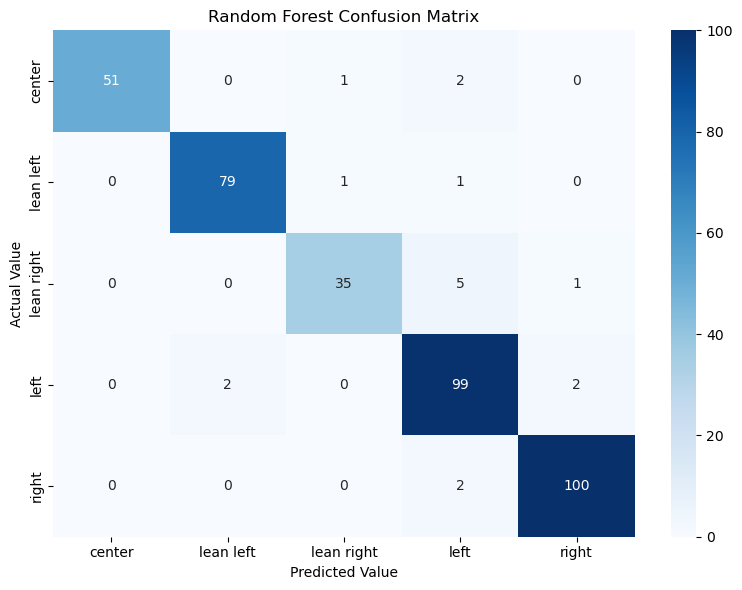

In [18]:
def plot_rf_confusion_matrix():
    if os.path.exists("rf_model.pkl"):
        with open('rf_model.pkl', 'rb') as file:
            loaded_rf = pickle.load(file)
            y_pred = loaded_rf.predict(X_test_rf)
            cm = confusion_matrix(y_true=y_test_rf, y_pred=y_pred)

            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
            
            plt.title('Random Forest Confusion Matrix')
            plt.xlabel('Predicted Value')
            plt.ylabel('Actual Value')
            plt.tight_layout()
            plt.show()
    else:
        print("Random Forest model not found. Run train_random_forest() first.")

plot_rf_confusion_matrix()

In [19]:
def get_performance_random_forest():
    if os.path.exists("rf_model.pkl"):
        with open('rf_model.pkl', 'rb') as file:
            loaded_rf = pickle.load(file)
            y_pred = loaded_rf.predict(X_test_rf)

            labels = le.classes_
            print("Random Forest Evaluation")
            print('-'*54)
            print(classification_report(y_true=y_test_rf, y_pred=y_pred, target_names=labels))

            y_prob = loaded_rf.predict_proba(X_test_rf)
            print(f"Random Forest ROC AUC: {roc_auc_score(y_test_rf, y_prob, multi_class='ovr'):.4f}")
    else:
        print("Random Forest model not found. Run train_random_forest() first.")

get_performance_random_forest()

Random Forest Evaluation
------------------------------------------------------
              precision    recall  f1-score   support

      center       1.00      0.94      0.97        54
   lean left       0.98      0.98      0.98        81
  lean right       0.95      0.85      0.90        41
        left       0.91      0.96      0.93       103
       right       0.97      0.98      0.98       102

    accuracy                           0.96       381
   macro avg       0.96      0.94      0.95       381
weighted avg       0.96      0.96      0.96       381

Random Forest ROC AUC: 0.9972


In [21]:
import pandas as pd
from IPython.display import display

data = {
    'Model': [
        'Random Forest', 
        'Naive Bayes', 
        'Logistic Regression', 
        'Support Vector Machine (SVM)'
    ],
    'Accuracy': [0.96, 0.88, 0.87, 0.85],
    'Macro Precision': [0.97, 0.87, 0.88, 0.86],
    'Macro Recall': [0.95, 0.86, 0.86, 0.83],
    'Macro F1-Score': [0.96, 0.87, 0.87, 0.84],
    'ROC-AUC': [0.9981, 0.9827, 0.9824, 0.9804]
}

df_comparison = pd.DataFrame(data)

df_comparison.set_index('Model', inplace=True)

print("Model Evaluation Comparison:")
display(df_comparison)

Model Evaluation Comparison:


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.96,0.97,0.95,0.96,0.9981
Naive Bayes,0.88,0.87,0.86,0.87,0.9827
Logistic Regression,0.87,0.88,0.86,0.87,0.9824
Support Vector Machine (SVM),0.85,0.86,0.83,0.84,0.9804


In [20]:
def show_ner(title):
    entities = perform_ner(title)
    if not entities:
        print("No named entities found.")
        return
    print(f"\nNamed Entities in: '{title}'")
    for text, label in entities:
        print(f"  {text} -> {label}")

def get_user_ner_vector(title):
    ent_dict = get_entity_dictionary(title)
    
    parts = []
    for ner_type in ['ORG', 'PERSON', 'GPE', 'NORP']:
        vec = ner_vectorizers[ner_type]
        mat = vec.transform([ent_dict[ner_type]]).toarray()
        parts.append(mat)
        
    return np.hstack(parts)

def main():
    current_title = "No Title"
    current_category = "Unknown"
    active_model = "Naive Bayes"

    loaded_models = {}
    
    if os.path.exists('model.pkl'):
        with open('model.pkl', 'rb') as f: 
            loaded_models['Naive Bayes'] = pickle.load(f)
            
    if os.path.exists('svm_model.pkl') and os.path.exists('svm_scaler.pkl'):
        with open('svm_model.pkl', 'rb') as f: 
            loaded_models['SVM'] = pickle.load(f)
        with open('svm_scaler.pkl', 'rb') as f: 
            loaded_models['SVM_scaler'] = pickle.load(f)
            
    if os.path.exists('lr_model.pkl') and os.path.exists('lr_scaler.pkl'):
        with open('lr_model.pkl', 'rb') as f: 
            loaded_models['Logistic Regression'] = pickle.load(f)
        with open('lr_scaler.pkl', 'rb') as f: 
            loaded_models['LR_scaler'] = pickle.load(f)
            
    if os.path.exists('rf_model.pkl'):
        with open('rf_model.pkl', 'rb') as f: 
            loaded_models['Random Forest'] = pickle.load(f)

    while True:
        print("\n" + "="*40)
        print("Political Bias Classification System")
        print("="*40)
        print(f"Your Title    : {current_title}")
        print(f"Bias Category : {current_category}")
        print(f"Active Model  : {active_model}")
        print("-" * 40)
        print("1. Input an article title")
        print("2. View NER")
        print("3. Change Active Model")
        print("4. Exit")

        choice = input("  >> ").strip()

        if choice == "1":
            input_title = input("\nEnter article title: ")
            source = input("\nEnter article source: ")
            current_title = input_title + " " + source
            
            if len(current_title.split(' ')) > 3:
                tokens  = preprocessing(current_title)
                w2v_vec = get_mean_vector(tokens).reshape(1, -1)
                tfidf_v = ngram_model.transform([current_title]).toarray()
                ner_vec = get_user_ner_vector(current_title)
     
                user_vec = np.hstack((w2v_vec, tfidf_v, ner_vec))
                pred = None
                
                if active_model == "Naive Bayes":
                    if 'Naive Bayes' in loaded_models:
                        user_vec_pos = user_vec - feat_min
                        pred = loaded_models['Naive Bayes'].predict(user_vec_pos)
                        
                elif active_model == "SVM":
                    if 'SVM' in loaded_models and 'SVM_scaler' in loaded_models:
                        user_vec_scaled = loaded_models['SVM_scaler'].transform(user_vec)
                        pred = loaded_models['SVM'].predict(user_vec_scaled)
                        
                elif active_model == "Logistic Regression":
                    if 'Logistic Regression' in loaded_models and 'LR_scaler' in loaded_models:
                        user_vec_scaled = loaded_models['LR_scaler'].transform(user_vec)
                        pred = loaded_models['Logistic Regression'].predict(user_vec_scaled)
                        
                elif active_model == "Random Forest":
                    if 'Random Forest' in loaded_models:
                        pred = loaded_models['Random Forest'].predict(user_vec)

                if pred is not None:
                    current_category = le.inverse_transform(pred)[0]
                    print(f"\nPredicted bias using {active_model}: {current_category}")
                else:
                    print(f"\nPrediction failed. Ensure {active_model} is fully trained and saved.")
                    current_category = "Unknown"
            else:
                print("Please input a title more than 3 words!")

        elif choice == "2":
            if current_title == "No Title":
                print("\nPlease enter a title first (option 1).")
            else:
                show_ner(current_title)

        elif choice == "3":
            print("\nSelect a model to use:")
            print("1. Naive Bayes")
            print("2. Support Vector Machine (SVM)")
            print("3. Logistic Regression")
            print("4. Random Forest")
            model_choice = input("  >> ").strip()
            
            if model_choice == "1": active_model = "Naive Bayes"
            elif model_choice == "2": active_model = "SVM"
            elif model_choice == "3": active_model = "Logistic Regression"
            elif model_choice == "4": active_model = "Random Forest"
            else: print("\nInvalid choice. Keeping current model.")
            
            print(f"\nActive model is now: {active_model}")

        elif choice == "4":
            print("\nExiting...")
            break
        else:
            print("\nInvalid choice. Please input number 1–4.")

# Run the system
main()


Political Bias Classification System
Your Title    : No Title
Bias Category : Unknown
Active Model  : Naive Bayes
----------------------------------------
1. Input an article title
2. View NER
3. Change Active Model
4. Exit

Predicted bias using Naive Bayes: center

Political Bias Classification System
Your Title    : Why Socialism? Monthly Review
Bias Category : center
Active Model  : Naive Bayes
----------------------------------------
1. Input an article title
2. View NER
3. Change Active Model
4. Exit

Predicted bias using Naive Bayes: left

Political Bias Classification System
Your Title    : Capital in the Twenty-First Century Thomas Piketty
Bias Category : left
Active Model  : Naive Bayes
----------------------------------------
1. Input an article title
2. View NER
3. Change Active Model
4. Exit

Invalid choice. Please input number 1–4.

Political Bias Classification System
Your Title    : Capital in the Twenty-First Century Thomas Piketty
Bias Category : left
Active Model  : 